# Chroma Vector Database Tutorial

빠른 이미지 검색을 위한 벡터 데이터베이스 튜토리얼

> 유튜브 [빵형의 개발도상국](https://www.youtube.com/@bbanghyong)

In [2]:
!pip install -q chromadb transformers

## Dataset

Food-11 데이터셋 중 evaluation 데이터 10장씩

https://www.kaggle.com/datasets/trolukovich/food11-image-dataset

In [3]:
!wget -q https://github.com/kairess/toy-datasets/raw/master/Food-11.zip
!unzip -q Food-11.zip

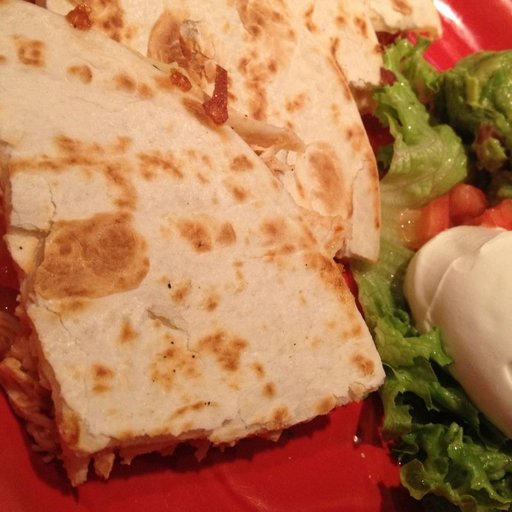

In [4]:
from PIL import Image

img = Image.open("test/Bread/0.jpg")

img

## Image Vectorizer 모델 로드

https://huggingface.co/facebook/dino-vits16

In [6]:
from transformers import ViTFeatureExtractor, ViTModel

feature_extractor = ViTFeatureExtractor.from_pretrained('facebook/dino-vits16')
model = ViTModel.from_pretrained('facebook/dino-vits16').to("mps")

print("Models loaded!")

pytorch_model.bin:   0%|          | 0.00/86.7M [00:00<?, ?B/s]

Some weights of ViTModel were not initialized from the model checkpoint at facebook/dino-vits16 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Models loaded!


model.safetensors:   0%|          | 0.00/86.7M [00:00<?, ?B/s]

## 임베딩

In [9]:
img_tensor = feature_extractor(images=img, return_tensors="pt").to("mps")
outputs = model(**img_tensor)

embedding = outputs.pooler_output.detach().cpu().numpy().squeeze()

embedding

array([ 0.7324314 , -0.8747861 ,  0.8791819 , -0.8292552 , -0.9641658 ,
        0.65804464, -0.9994773 ,  0.8654576 ,  0.3977437 ,  0.6499109 ,
        0.97225547, -0.9628822 , -0.9951026 ,  0.9984601 , -0.9660014 ,
       -0.97563154,  0.99053824,  0.904016  ,  0.9982728 , -0.99711555,
       -0.775966  , -0.8452076 ,  0.6137477 , -0.999759  ,  0.92467034,
        0.98607725, -0.9192428 ,  0.9992337 , -0.9999266 , -0.9877238 ,
        0.9608279 , -0.68326956,  0.9484713 , -0.99986553, -0.08175894,
        0.57831943,  0.96476364,  0.99753904, -0.9038369 ,  0.9992945 ,
        0.04790148,  0.8820472 ,  0.99910444, -0.82384205, -0.42999232,
       -0.6966999 , -0.99994844,  0.89607096,  0.0098292 , -0.83496886,
       -0.7228539 ,  0.17368881,  0.80459774,  0.19035548,  0.5046775 ,
        0.7446695 , -0.6924421 , -0.89501446,  0.7600931 ,  0.997836  ,
        0.6844888 , -0.9999696 , -0.9819202 ,  0.37635988, -0.97441447,
       -0.94161457, -0.44656053,  0.9985038 ,  0.27232423,  0.72

In [10]:
embedding.shape

(384,)

## Chroma DB 시작

https://www.trychroma.com

In [11]:
import chromadb

client = chromadb.Client()

collection = client.create_collection("foods")

## 모든 이미지 벡터화

In [12]:
from glob import glob

img_list = sorted(glob("test/*/*.jpg"))

len(img_list)

110

In [14]:
from tqdm import tqdm

embeddings = []
metadatas = []
ids = []

for i, img_path in enumerate(tqdm(img_list)):
    img = Image.open(img_path)
    cls = img_path.split("/")[1]

    img_tensor = feature_extractor(images=img, return_tensors="pt").to("mps")
    outputs = model(**img_tensor)

    embedding = outputs.pooler_output.detach().cpu().numpy().squeeze().tolist()

    embeddings.append(embedding)

    metadatas.append({
        "uri": img_path,
        "name": cls
    })

    ids.append(str(i))

print("Done!")

100%|██████████| 110/110 [00:01<00:00, 103.63it/s]

Done!


## 임베딩을 데이터베이스에 저장

In [15]:
collection.add(
    embeddings=embeddings,
    metadatas=metadatas,
    ids=ids,
)

## Test1

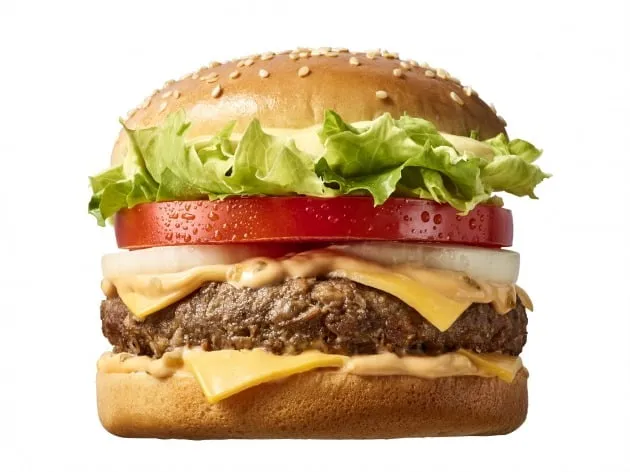

In [16]:
import requests

test_img = Image.open(requests.get("https://i.ibb.co/7Ksr5mw/yNp6qTS.png", stream=True).raw).convert("RGB")

test_img

In [18]:
test_img_tensor = feature_extractor(images=test_img, return_tensors="pt").to("mps")
test_outputs = model(**test_img_tensor)

test_embedding = test_outputs.pooler_output.detach().cpu().numpy().squeeze().tolist()

len(test_embedding)

384

In [19]:
query_result = collection.query(
    query_embeddings=[test_embedding],
    n_results=3,
)

query_result

{'ids': [['8', '2', '108']],
 'embeddings': None,
 'documents': [[None, None, None]],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'uri': 'test/Bread/8.jpg', 'name': 'Bread'},
   {'uri': 'test/Bread/2.jpg', 'name': 'Bread'},
   {'name': 'Vegetable-Fruit', 'uri': 'test/Vegetable-Fruit/8.jpg'}]],
 'distances': [[137.68777465820312, 238.01815795898438, 297.0668640136719]]}

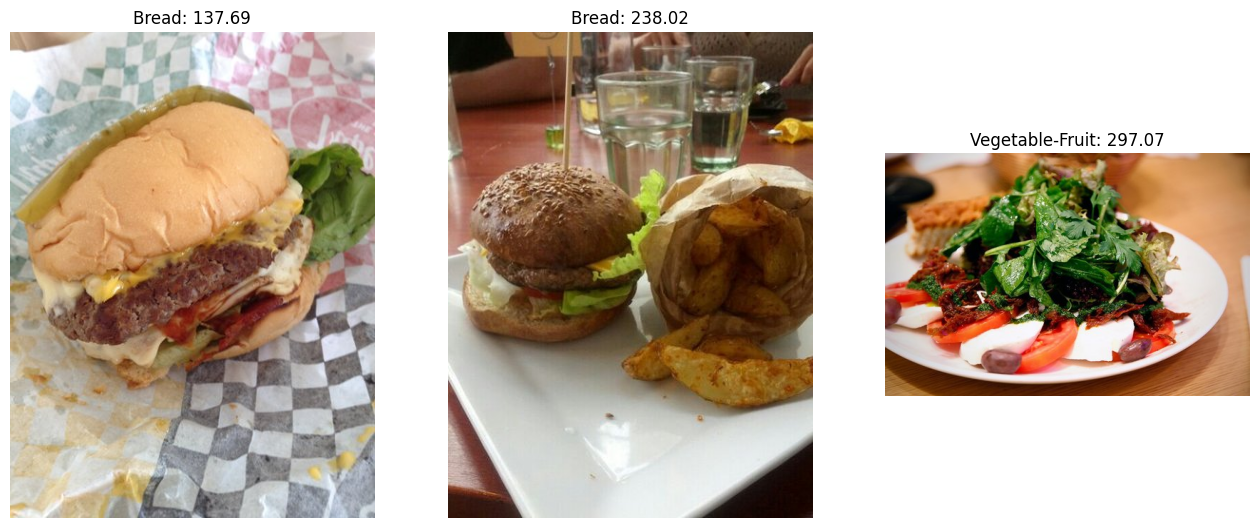

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 10))

for i, metadata in enumerate(query_result["metadatas"][0]):
    distance = query_result["distances"][0][i]

    axes[i].imshow(Image.open(metadata["uri"]))
    axes[i].set_title(f"{metadata['name']}: {distance:.2f}")
    axes[i].axis("off")

## 테스트를 위한 함수화

In [23]:
def query(img_url, n_results=3):
    test_img = Image.open(requests.get(img_url, stream=True).raw).convert("RGB")

    test_img_tensor = feature_extractor(images=test_img, return_tensors="pt").to("mps")
    test_outputs = model(**test_img_tensor)

    test_embedding = test_outputs.pooler_output.detach().cpu().numpy().squeeze().tolist()

    query_result = collection.query(
        query_embeddings=[test_embedding],
        n_results=n_results,
    )

    fig, axes = plt.subplots(1, 4, figsize=(16, 10))

    axes[0].imshow(test_img)
    axes[0].set_title("Query")
    axes[0].axis("off")

    for i, metadata in enumerate(query_result["metadatas"][0]):
        distance = query_result["distances"][0][i]

        axes[i+1].imshow(Image.open(metadata["uri"]))
        axes[i+1].set_title(f"{metadata['name']}: {distance:.2f}")
        axes[i+1].axis("off")

    return query_result

## Test2

{'ids': [['21', '47', '54']],
 'embeddings': None,
 'documents': [[None, None, None]],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'uri': 'test/Dessert/1.jpg', 'name': 'Dessert'},
   {'uri': 'test/Fried food/7.jpg', 'name': 'Fried food'},
   {'name': 'Meat', 'uri': 'test/Meat/4.jpg'}]],
 'distances': [[266.613037109375, 268.153076171875, 281.3613586425781]]}

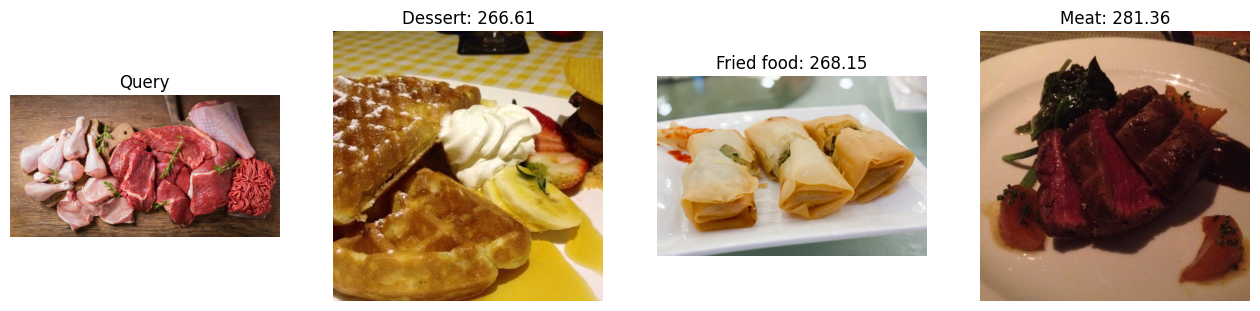

In [24]:
query("https://i.ibb.co/JmpXmvx/QCado9g.jpg")

{'ids': [['13', '14', '10']],
 'embeddings': None,
 'documents': [[None, None, None]],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'name': 'Dairy product', 'uri': 'test/Dairy product/3.jpg'},
   {'name': 'Dairy product', 'uri': 'test/Dairy product/4.jpg'},
   {'uri': 'test/Dairy product/0.jpg', 'name': 'Dairy product'}]],
 'distances': [[205.43856811523438, 231.00950622558594, 256.45538330078125]]}

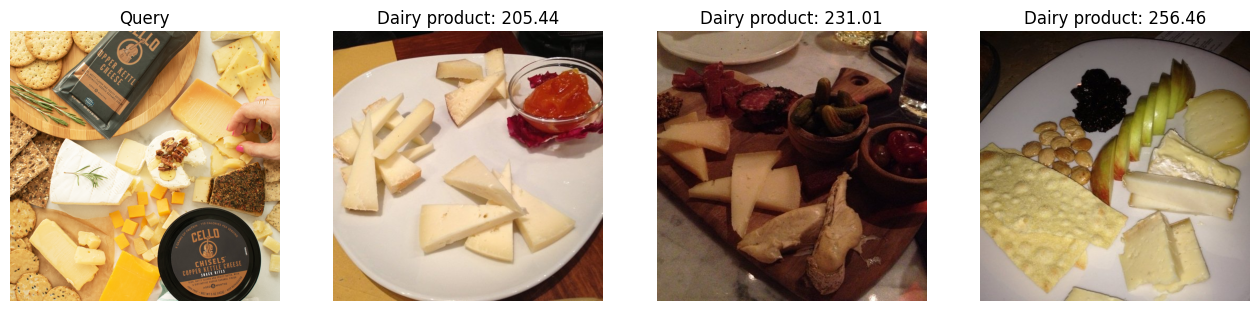

In [25]:
query("https://i.ibb.co/X5dkHGF/lf5C0LI.png")

In [ ]:
query("https://i.ibb.co/ZVx2Fn8/WlLv0i9.png")